# Performance Measures (part 2): The Trade-off Precision / Recall

## Starting Point

We rebuilt the bare minimum of the previous notebook so that it could run on its own: we downloaded MNIST, assembled the binary target of the "5-detector," and trained the SGD.

In [1]:
from sklearn.datasets import fetch_openml

# as_frame=False to receive NumPy arrays instead of a Pandas DataFrame
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

# MNIST match is coming up: 60,000 for training, 10,000 for testing
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Tags to boolean: True if it is a 5
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [2]:
from sklearn.linear_model import SGDClassifier

# random_state=42 so that the result is reproducible in class
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## 1. How Does the Model Actually Make a Decision? The Score and the Threshold

The SGDClassifier is a **linear model**. For each image, it computes a **score** by multiplying each of the 784 pixels by its corresponding weight, summing the results, and adding the bias.

$$ \text{score} = w_1 x_1 + w_2 x_2 + \dots + w_{784} x_{784} + b $$

This score acts as a **confidence indicator**: the higher the score, the more confident the model is that the image is a 5; the more negative the score, the more confident it is that the image is **not** a 5.

The model then applies a simple decision rule using a **threshold**:

- If `score >= threshold` → predict **"it's a 5"**
- If `score < threshold` → predict **"it's not a 5"**

Let's inspect the score for a specific image. We'll use the first image in the dataset, which happens to be a 5:

In [3]:
print(y_train[0])

5


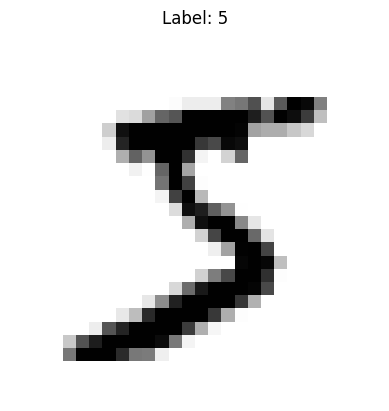

In [4]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0].reshape(28,28), cmap="binary")
plt.title(f"Label: {y_train[0]}")
plt.axis("off");

In [5]:
some_digit = X_train[0]   # This image is a 5
y_score = sgd_clf.predict([some_digit])
y_score

array([ True])

In [6]:
# decision_function() gives us the raw SCORE, not the decision already made
some_digit = X_train[0]   # This image is a 5
y_score = sgd_clf.decision_function([some_digit])
y_score

array([2164.22030239])

That number is the score for that image. By default, `SGDClassifier` uses a **threshold = 0**: if the score is greater than 0, it says "it's a 5".

Let's verify that with a threshold of 0 it does indeed classify it as a 5:

In [7]:
threshold = 0
y_pred_some = (y_score > threshold)
y_pred_some   # True -> with a threshold of 0 it says "it's a 5"

array([ True])

Now let's **raise the threshold** to a high value. The same score as before no longer exceeds it, so the model stops recognizing 5:

In [8]:
threshold = 3000
y_pred_some = (y_score > threshold)
y_pred_some   # False -> with a threshold of 3000 it is no longer detected

array([False])

This confirms the key intuition:

> **Raising the threshold makes the model more demanding and causes it to lose positives (recall decreases). Lowering it makes it more permissive (recall increases but false positives are included).**

Same image, same model, same score: the only thing that changed was the threshold, and with that, the decision changed.

## 2. Honest Scores for the Entire Set: `cross_val_predict`

To determine a good threshold, we need the scores for **all** of the training images. But there's a problem: if we ask the model for the scores of the same images it trained on, those scores would be **too optimistic** (the model has already "seen the responses").

`cross_val_predict` solves this with **cross-validation**: it divides the set into blocks (`cv=3`), trains with the ones it trained on, and predicts based on the one it left out, rotating through them. This way, **each image receives a score from a model that did NOT use it for training** → honest scores.

The key detail is `method="decision_function"`: instead of returning the predictions (`True`/`False`), we ask for the **raw scores**, which are the raw material for threshold sweeps.

In [9]:
from sklearn.model_selection import cross_val_predict

# NOTE: method="decision_function" -> returns SCORES, not predictions
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                            method="decision_function")
y_scores[:10]   # the first 10 scores

array([  1200.93051237, -26883.79202424, -33072.03475406, -15919.5480689 ,
       -20003.53970191, -16652.87731528, -14276.86944263, -23328.13728948,
        -5172.79611432, -13873.5025381 ])

## 3. The Precision and Recall Curve vs. Threshold

Using the scores for all images, `precision_recall_curve` calculates the precision and recall **for all possible thresholds** at once.

In [10]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Note: The function adds a final artificial point (precision=1, recall=0)
# which corresponds to an "infinite threshold" and has no associated threshold.
# That's why precisions and recalls have one more element than thresholds:
print("precisions:", precisions.shape)
print("recalls:   ", recalls.shape)
print("thresholds:", thresholds.shape)

precisions: (60001,)
recalls:    (60001,)
thresholds: (60000,)


Now we plot precision and recall **as a function of the threshold**. We mark the threshold 3000 as a reference. This is Figure 3-5 from the book.

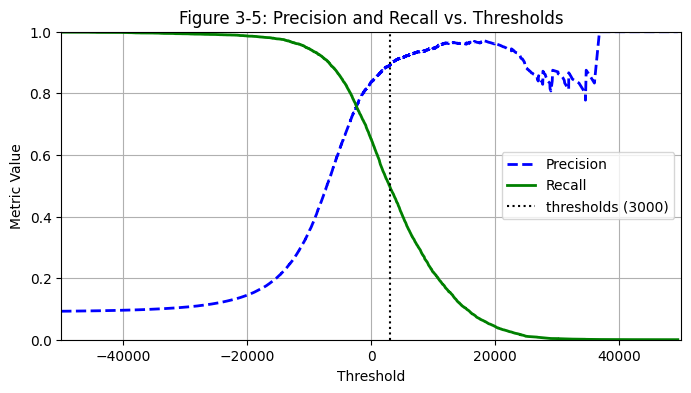

In [ ]:
threshold = 3000

plt.figure(figsize=(8, 4))
# precisions[:-1] and recalls[:-1]: we remove that last artificial point
# so they match thresholds when plotting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="thresholds (3000)")

plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Figure 3-5: Precision and Recall vs. Thresholds")
plt.legend(loc="center right")
plt.grid(True)
plt.axis([-50000, 50000, 0, 1])
plt.show()

How to read it, and why it's a trade-off illustrated:

- **Recall (green) only decreases** as we raise the threshold: the more demanding we are, the more real 5s we miss. Its curve is **smooth**, because when you raise the threshold you never recover a 5 you've already lost.

- **Accuracy (blue) generally increases**, but it appears **shaky** on the right: sometimes it decreases when the threshold is raised, because it depends on which image enters or exits at each step.

- **There is no point where both are at their maximum simultaneously.** Where they intersect, they are worth roughly the same.

Another useful view is to plot **precision versus recall** directly. This shows where the precision drops off.

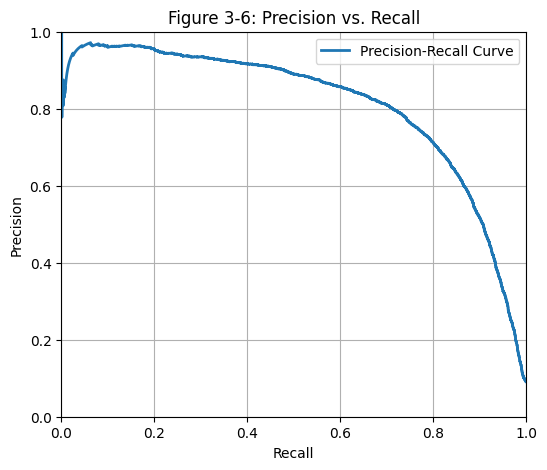

In [12]:
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, linewidth=2, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Figure 3-6: Precision vs. Recall")
plt.legend()
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.show()

Note that accuracy **drops sharply around 80% recall**. The practical recommendation is to choose a point *just before* that drop.

## 4. Choosing a Threshold for Target Accuracy (the 90% Example)

Suppose the project requires **90% accuracy**. We look for the **lowest threshold** that guarantees this.

NumPy trick: `(precisions >= 0.90)` returns an array of `True`/`False` values, and `.argmax()` returns the index of the **first** `True` (the first threshold that reaches 90%).

In [13]:
import numpy as np

idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194991439557

We now make predictions using that threshold (instead of `predict()`, which would use threshold 0):

In [14]:
# We apply OUR threshold to the scores
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [15]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_train_5, y_train_pred_90))
print("Recall:   ", recall_score(y_train_5, y_train_pred_90))

Precision: 0.9000345901072293
Recall:    0.4799852425751706
